# 03 — Model Selection and Evaluation

This notebook consumes only the persisted Dry Bean preparation handoff. It performs a train-only, five-fold stratified multiclass search; uses validation only after candidate and feature-policy tuning are frozen; and keeps test structurally sealed for notebook 04. No final model, serialized pipeline, inference bundle, binary threshold, or test metric is produced here.


## 1. Model-Selection Context and Boundary

The task is an educational seven-class benchmark on the frozen static snapshot. Macro F1 is primary because every class contributes equally despite unequal support. Balanced accuracy, macro recall, weighted F1, accuracy (context only), per-class metrics, confusion evidence, and multiclass log loss are secondary. Operational validity and inference-time feature availability remain unconfirmed.


In [17]:
from __future__ import annotations

import inspect
import json
import os
import sys
import warnings
from pathlib import Path


def _bootstrap_project_root() -> Path:
    configured = os.getenv("DATASET_STUDY_ROOT")
    candidates = ([Path(configured).expanduser()] if configured else []) + [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        root = candidate.resolve()
        if (root / "scripts" / "prepare_data.py").is_file() and (root / "scripts" / "select_models.py").is_file():
            return root
    raise RuntimeError("Dataset-study project root not found.")


PROJECT_ROOT = _bootstrap_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)

from scripts.export_figures import export_figure
from scripts.prepare_data import load_and_validate_preparation_handoff
from scripts.project_context import get_project_context
from scripts.select_models import (
    MULTICLASS_ARTIFACT_FILENAMES,
    analyze_overlap_confusion_hypothesis,
    analyze_repeated_profile_sensitivity,
    build_candidate_pipeline,
    build_cross_validation,
    build_multiclass_candidate_results,
    build_multiclass_model_selection_handoff,
    build_multiclass_model_selection_manifest,
    build_multiclass_scoring_contract,
    build_multiclass_selection_analysis,
    build_multiclass_validation_evidence,
    describe_multiclass_cv_folds,
    evaluate_multiclass_classifier,
    evaluate_multiclass_feature_policy_cv,
    load_and_validate_model_selection_handoff,
    run_multiclass_model_search,
    select_multiclass_candidate_model,
    sha256_file,
    summarize_multiclass_search_results,
    validate_multiclass_feature_partition_roles,
    validate_multiclass_model_selection_contract,
    write_multiclass_model_selection_artifacts,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (9, 5)
print("Multiclass model-selection utilities loaded.")


Multiclass model-selection utilities loaded.


## 2. Independent Preparation-Handoff Loading

The composite handoff is the sole data entry point. Its loader verifies all preparation JSON and CSV hashes, including structural test integrity. Only train, validation, and declarative manifests are retained; no test working variable is created.


In [18]:
PROJECT = get_project_context()
DATASET_SLUG = "dry-bean"
PREPARATION_HANDOFF_PATH = Path("artifacts/preparation/dry-bean/preparation-handoff.json")
MODEL_SELECTION_ROOT = Path("artifacts/model-selection/dry-bean")

preparation = load_and_validate_preparation_handoff(
    project_root=PROJECT.root,
    preparation_handoff_path=PREPARATION_HANDOFF_PATH,
)
train_frame = preparation.train
validation_frame = preparation.validation
preparation_manifests = preparation.manifests

split_manifest = preparation_manifests["split_manifest"]
feature_manifest = preparation_manifests["feature_manifest"]
preparation_manifest = preparation_manifests["preparation_manifest"]
preparation_handoff_manifest = preparation_manifests["preparation_handoff"]
quality_evidence = preparation_manifests["quality_evidence"]

TEST_INTEGRITY_REFERENCE = {
    "path": split_manifest["partition_paths"]["test"],
    "row_count": split_manifest["row_counts"]["test"],
    "sha256": split_manifest["partition_sha256"]["test"],
    "sealed": quality_evidence["readiness"]["test_partition_sealed"],
    "evaluated": quality_evidence["readiness"]["test_partition_evaluated"],
}
del preparation

assert preparation_handoff_manifest["consumer_contract"] == {
    "prepared_and_partitions_are_frozen": True,
    "model_selection_must_not_resplit": True,
    "test_partition_sealed": True,
    "test_partition_evaluated": False,
}
print("Preparation handoff integrity gate: PASSED")
print("Train shape:", train_frame.shape)
print("Validation shape:", validation_frame.shape)
print("Test integrity reference only:", json.dumps(TEST_INTEGRITY_REFERENCE, indent=2))


Preparation handoff integrity gate: PASSED
Train shape: (9527, 17)
Validation shape: (2042, 17)
Test integrity reference only: {
  "path": "data/processed/dry-bean/splits/stratified-70-15-15-seed-42/test.csv",
  "row_count": 2042,
  "sha256": "5e17c1346e67cb4a786ebd11162b7e45099ded342b9de9755ab4f18f4068c175",
  "sealed": true,
  "evaluated": false
}


## 3. Frozen Feature, Target, and Partition Roles

All 16 predictors remain numeric and ordered. `Class` remains a readable nominal label; the 0–6 mapping is deterministic metadata, never an ordinal or positive-class contract. Technical row-occurrence membership is preserved without claiming entity disjointness.


In [19]:
TARGET_COLUMN = feature_manifest["target_column"]
TARGET_CLASSES = tuple(feature_manifest["target_classes"])
TARGET_ENCODING = dict(feature_manifest["target_encoding_contract"])
FEATURE_COLUMNS = tuple(feature_manifest["feature_columns"])
IDENTIFIER_COLUMNS = tuple(feature_manifest["identifier_columns"])

roles = validate_multiclass_feature_partition_roles(
    train=train_frame,
    validation=validation_frame,
    feature_columns=FEATURE_COLUMNS,
    identifier_columns=IDENTIFIER_COLUMNS,
    target_column=TARGET_COLUMN,
    target_classes=TARGET_CLASSES,
    target_encoding=TARGET_ENCODING,
)
X_train = roles.x_train
y_train = roles.y_train
X_validation = roles.x_validation
y_validation = roles.y_validation
del roles, train_frame, validation_frame

assert TARGET_CLASSES == ("SEKER", "BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SIRA")
assert feature_manifest["problem_type"] == "multiclass_classification"
assert feature_manifest["positive_target_class"] is None
assert split_manifest["membership_kind"] == "technical_row_occurrence"
assert split_manifest["entity_disjointness_status"] == "not_claimed_without_source_identifiers"
display(pd.DataFrame({"feature": FEATURE_COLUMNS, "technical_order": range(len(FEATURE_COLUMNS))}))
print("Target classes:", TARGET_CLASSES)
print("Target encoding (deterministic, not ordinal):", TARGET_ENCODING)


,feature,technical_order
0,Area,0
1,Perimeter,1
2,MajorAxisLength,2
3,MinorAxisLength,3
4,AspectRatio,4
5,Eccentricity,5
6,ConvexArea,6
7,EquivDiameter,7
8,Extent,8
9,Solidity,9


Target classes: ('SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SIRA')
Target encoding (deterministic, not ordinal): {'SEKER': 0, 'BARBUNYA': 1, 'BOMBAY': 2, 'CALI': 3, 'DERMASON': 4, 'HOROZ': 5, 'SIRA': 6}


## 4. Multiclass Evaluation and Cross-Validation Contract

Five-fold `StratifiedKFold` operates on train only. A practical tie is a validation macro-F1 difference of at most 0.002 (0.2 percentage points), small enough to treat near-identical snapshot results as practically equivalent while still requiring explicit class-balanced tie-breaks. Candidates must exceed Dummy macro F1 by more than 0.02.


In [20]:
RANDOM_SEED = 42
SEARCH_N_JOBS = 1
ESTIMATOR_N_JOBS = 1
PRACTICAL_TIE_TOLERANCE = 0.002
DUMMY_MACRO_F1_MARGIN = 0.02

MODEL_SELECTION_CONTRACT = validate_multiclass_model_selection_contract({
    "problem_type": "multiclass_classification",
    "target_semantics": "nominal_unordered",
    "primary_metric": "macro_f1",
    "refit_metric": "macro_f1",
    "cv": {"strategy": "StratifiedKFold", "n_splits": 5, "shuffle": True, "random_state": RANDOM_SEED},
    "dummy_macro_f1_margin": DUMMY_MACRO_F1_MARGIN,
    "practical_tie_tolerance": PRACTICAL_TIE_TOLERANCE,
    "decision_rule": "argmax_class_score_or_probability",
    "positive_class": None,
    "binary_threshold": {"status": "not_applicable", "value": None},
    "operational_threshold": {"status": "not_applicable", "value": None},
    "test_partition_sealed": True,
    "test_partition_evaluated": False,
    "operational_validity": "unconfirmed",
})
SCORING = build_multiclass_scoring_contract()
CV = build_cross_validation(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
CV_FOLD_DISTRIBUTIONS = describe_multiclass_cv_folds(
    cv=CV, x=X_train, y=y_train, target_classes=TARGET_CLASSES
)
display(pd.DataFrame(CV_FOLD_DISTRIBUTIONS))


,fold,train_rows,validation_rows,train_class_counts,validation_class_counts,all_classes_present
0,1,7621,1906,"{'SEKER': 1135, 'BARBUNYA': 740, 'BOMBAY': 292...","{'SEKER': 284, 'BARBUNYA': 185, 'BOMBAY': 73, ...",True
1,2,7621,1906,"{'SEKER': 1135, 'BARBUNYA': 740, 'BOMBAY': 292...","{'SEKER': 284, 'BARBUNYA': 185, 'BOMBAY': 73, ...",True
2,3,7622,1905,"{'SEKER': 1135, 'BARBUNYA': 740, 'BOMBAY': 292...","{'SEKER': 284, 'BARBUNYA': 185, 'BOMBAY': 73, ...",True
3,4,7622,1905,"{'SEKER': 1135, 'BARBUNYA': 740, 'BOMBAY': 292...","{'SEKER': 284, 'BARBUNYA': 185, 'BOMBAY': 73, ...",True
4,5,7622,1905,"{'SEKER': 1136, 'BARBUNYA': 740, 'BOMBAY': 292...","{'SEKER': 283, 'BARBUNYA': 185, 'BOMBAY': 73, ...",True


## 5. Candidate Families, Dummy Baseline, and Fold-Safe Pipelines

Logistic Regression is the regularized linear reference and uses `StandardScaler` inside each fold. Decision Tree is an interpretable nonlinear reference. Random Forest and HistGradientBoosting cover interaction-rich tabular ensembles. Tree families do not scale. Class-weight alternatives are searched where supported; no resampling or new dependency is introduced.


In [21]:
assert "class_weight" in inspect.signature(HistGradientBoostingClassifier).parameters

BASELINE_ESTIMATOR = DummyClassifier(strategy="prior")
CANDIDATE_SPECS = [
    {
        "model_id": "logistic_regression",
        "family": "LogisticRegression",
        "estimator": LogisticRegression(solver="lbfgs", max_iter=2000, random_state=RANDOM_SEED),
        "scale_features": True,
        "search_strategy": "GridSearchCV",
        "search_space": {"model__C": [0.1, 1.0], "model__class_weight": [None, "balanced"]},
    },
    {
        "model_id": "decision_tree",
        "family": "DecisionTreeClassifier",
        "estimator": DecisionTreeClassifier(random_state=RANDOM_SEED),
        "scale_features": False,
        "search_strategy": "GridSearchCV",
        "search_space": {
            "model__max_depth": [8, None],
            "model__min_samples_leaf": [1, 5],
            "model__class_weight": [None, "balanced"],
        },
    },
    {
        "model_id": "random_forest",
        "family": "RandomForestClassifier",
        "estimator": RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=ESTIMATOR_N_JOBS),
        "scale_features": False,
        "search_strategy": "RandomizedSearchCV",
        "search_space": {
            "model__n_estimators": [120, 240],
            "model__max_depth": [None, 16],
            "model__min_samples_leaf": [1, 3],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
        "n_iter": 8,
    },
    {
        "model_id": "hist_gradient_boosting",
        "family": "HistGradientBoostingClassifier",
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_SEED),
        "scale_features": False,
        "search_strategy": "RandomizedSearchCV",
        "search_space": {
            "model__learning_rate": [0.05, 0.1],
            "model__max_iter": [150, 250],
            "model__max_leaf_nodes": [15, 31],
            "model__min_samples_leaf": [20, 40],
            "model__l2_regularization": [0.0, 1.0],
            "model__class_weight": [None, "balanced"],
        },
        "n_iter": 8,
    },
]

inventory = []
for spec in CANDIDATE_SPECS:
    grid_size = int(np.prod([len(values) for values in spec["search_space"].values()]))
    candidates = grid_size if spec["search_strategy"] == "GridSearchCV" else spec["n_iter"]
    inventory.append({
        "model_id": spec["model_id"], "family": spec["family"],
        "strategy": spec["search_strategy"], "declared_space": grid_size,
        "actual_candidates": candidates, "fits": candidates * 5,
        "scaling": "StandardScaler inside fold" if spec["scale_features"] else "none",
    })
display(pd.DataFrame(inventory))


,model_id,family,strategy,declared_space,actual_candidates,fits,scaling
0,logistic_regression,LogisticRegression,GridSearchCV,4,4,20,StandardScaler inside fold
1,decision_tree,DecisionTreeClassifier,GridSearchCV,8,8,40,none
2,random_forest,RandomForestClassifier,RandomizedSearchCV,24,8,40,none
3,hist_gradient_boosting,HistGradientBoostingClassifier,RandomizedSearchCV,64,8,40,none


## 6. Dummy Baseline and Family Search on Train


In [22]:
DUMMY_CV, DUMMY_PIPELINE = evaluate_multiclass_feature_policy_cv(
    model_id="dummy_prior",
    family="DummyClassifier",
    estimator=BASELINE_ESTIMATOR,
    selected_hyperparameters={},
    feature_policy="all_features",
    feature_columns=FEATURE_COLUMNS,
    scale_features=False,
    x_train=X_train,
    y_train=y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=SEARCH_N_JOBS,
)

SEARCH_OUTCOMES = {}
FAMILY_SUMMARIES = {}
FAMILY_CV_TABLES = []
WARNINGS_BY_MODEL = {}
for spec in CANDIDATE_SPECS:
    pipeline = build_candidate_pipeline(
        estimator=spec["estimator"],
        numerical_features=FEATURE_COLUMNS,
        categorical_features=(),
        scale_numerical=spec["scale_features"],
    )
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always")
        outcome = run_multiclass_model_search(
            model_id=spec["model_id"], family=spec["family"], pipeline=pipeline,
            search_strategy=spec["search_strategy"], search_space=spec["search_space"],
            x_train=X_train, y_train=y_train, scoring=SCORING, cv=CV,
            n_jobs=SEARCH_N_JOBS, random_state=RANDOM_SEED,
            n_iter=spec.get("n_iter"), error_score="raise",
        )
    summary, table = summarize_multiclass_search_results(outcome, n_splits=5)
    SEARCH_OUTCOMES[spec["model_id"]] = outcome
    FAMILY_SUMMARIES[spec["model_id"]] = summary
    FAMILY_CV_TABLES.append(table)
    WARNINGS_BY_MODEL[spec["model_id"]] = sorted({
        f"{item.category.__name__}: {item.message}" for item in captured
    })

family_comparison = pd.DataFrame(FAMILY_SUMMARIES.values()).sort_values(
    ["cv_macro_f1_mean", "model_id"], ascending=[False, True]
)
SHORTLIST_MODEL_IDS = tuple(family_comparison.head(2)["model_id"])
display(family_comparison[[
    "model_id", "family", "candidate_count", "number_of_fits",
    "cv_macro_f1_mean", "cv_macro_f1_std", "cv_balanced_accuracy_mean",
    "cv_macro_recall_mean", "cv_weighted_f1_mean", "cv_log_loss_mean",
]])
print("CV-only shortlist:", SHORTLIST_MODEL_IDS)


,model_id,family,candidate_count,number_of_fits,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_macro_recall_mean,cv_weighted_f1_mean,cv_log_loss_mean
3,hist_gradient_boosting,HistGradientBoostingClassifier,8,40,0.937012,0.003825,0.935424,0.935424,0.924310,0.258114
0,logistic_regression,LogisticRegression,4,20,0.935031,0.000996,0.933826,0.933826,0.922071,0.218538
2,random_forest,RandomForestClassifier,8,40,0.933343,0.003635,0.931656,0.931656,0.921274,0.342768
1,decision_tree,DecisionTreeClassifier,8,40,0.919904,0.009698,0.920557,0.920557,0.908862,0.662884


CV-only shortlist: ('hist_gradient_boosting', 'logistic_regression')


## 7. Feature and Imbalance Policy Sensitivity

The two CV-shortlisted families are evaluated under three controlled feature policies using the same train-only CV. `all_features` is the 16-feature baseline; `without_shape_factor_2` tests predictive sensitivity while provenance remains unresolved; `without_confirmed_derived` removes only the nine numerically confirmed derived dependencies. Extent and ShapeFactor2 remain in the latter variant.


In [23]:
CONFIRMED_DERIVED_FEATURES = (
    "AspectRatio", "Eccentricity", "EquivDiameter", "Solidity", "Roundness",
    "Compactness", "ShapeFactor1", "ShapeFactor3", "ShapeFactor4",
)
FEATURE_POLICIES = {
    "all_features": FEATURE_COLUMNS,
    "without_shape_factor_2": tuple(column for column in FEATURE_COLUMNS if column != "ShapeFactor2"),
    "without_confirmed_derived": tuple(column for column in FEATURE_COLUMNS if column not in CONFIRMED_DERIVED_FEATURES),
}

spec_by_id = {spec["model_id"]: spec for spec in CANDIDATE_SPECS}
POLICY_CV_SUMMARIES = {}
POLICY_PIPELINES = {}
policy_cv_rows = []
for base_model_id in SHORTLIST_MODEL_IDS:
    spec = spec_by_id[base_model_id]
    hyperparameters = SEARCH_OUTCOMES[base_model_id].best_parameters
    for policy_name, columns in FEATURE_POLICIES.items():
        candidate_id = f"{base_model_id}__{policy_name}"
        summary, pipeline = evaluate_multiclass_feature_policy_cv(
            model_id=candidate_id,
            family=spec["family"],
            estimator=spec["estimator"],
            selected_hyperparameters=hyperparameters,
            feature_policy=policy_name,
            feature_columns=columns,
            scale_features=spec["scale_features"],
            x_train=X_train,
            y_train=y_train,
            cv=CV,
            scoring=SCORING,
            n_jobs=SEARCH_N_JOBS,
        )
        summary["base_model_id"] = base_model_id
        summary["selected_hyperparameters"] = hyperparameters
        POLICY_CV_SUMMARIES[candidate_id] = summary
        POLICY_PIPELINES[candidate_id] = pipeline
        policy_cv_rows.append({
            "phase": "feature_policy_sensitivity", "model_id": candidate_id,
            "family": spec["family"], "feature_policy": policy_name,
            "search_strategy": "FrozenBestParametersCrossValidate",
            "candidate_index": 0,
            "parameters": json.dumps(hyperparameters, sort_keys=True, separators=(",", ":")),
            "rank_macro_f1": 1,
            "mean_cv_macro_f1": summary["cv_macro_f1_mean"],
            "std_cv_macro_f1": summary["cv_macro_f1_std"],
            "mean_cv_balanced_accuracy": summary["cv_balanced_accuracy_mean"],
            "mean_cv_macro_recall": summary["cv_macro_recall_mean"],
            "mean_cv_weighted_f1": summary["cv_weighted_f1_mean"],
            "mean_cv_accuracy": summary["cv_accuracy_mean"],
            "mean_cv_log_loss": summary["cv_log_loss_mean"],
            "search_duration_seconds": summary["duration_seconds"],
        })

policy_cv_table = pd.DataFrame(POLICY_CV_SUMMARIES.values()).sort_values(
    ["cv_macro_f1_mean", "model_id"], ascending=[False, True]
)
display(policy_cv_table[[
    "model_id", "family", "feature_policy", "feature_count",
    "cv_macro_f1_mean", "cv_macro_f1_std", "cv_balanced_accuracy_mean",
]])


,model_id,family,feature_policy,feature_count,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean
0,hist_gradient_boosting__all_features,HistGradientBoostingClassifier,all_features,16,0.937012,0.003825,0.935424
1,hist_gradient_boosting__without_shape_factor_2,HistGradientBoostingClassifier,without_shape_factor_2,15,0.936167,0.004014,0.934928
3,logistic_regression__all_features,LogisticRegression,all_features,16,0.935031,0.000996,0.933826
4,logistic_regression__without_shape_factor_2,LogisticRegression,without_shape_factor_2,15,0.934860,0.001422,0.933651
5,logistic_regression__without_confirmed_derived,LogisticRegression,without_confirmed_derived,7,0.919941,0.002835,0.917325
2,hist_gradient_boosting__without_confirmed_derived,HistGradientBoostingClassifier,without_confirmed_derived,7,0.918302,0.004924,0.916403


## 8. Validation Evaluation

Only the frozen policy candidates and the non-eligible Dummy baseline are now fitted on train and evaluated once on validation. Validation never enters CV or hyperparameter fitting.


In [24]:
DUMMY_PIPELINE.fit(X_train, y_train)
DUMMY_VALIDATION = evaluate_multiclass_classifier(
    estimator=DUMMY_PIPELINE,
    x=X_validation,
    y_true=y_validation,
    target_classes=TARGET_CLASSES,
)

FITTED_POLICY_PIPELINES = {}
VALIDATION_EVALUATIONS = {}
for candidate_id in sorted(POLICY_PIPELINES):
    columns = tuple(POLICY_CV_SUMMARIES[candidate_id]["feature_columns"])
    fitted = POLICY_PIPELINES[candidate_id]
    fitted.fit(X_train.loc[:, list(columns)], y_train)
    FITTED_POLICY_PIPELINES[candidate_id] = fitted
    VALIDATION_EVALUATIONS[candidate_id] = evaluate_multiclass_classifier(
        estimator=fitted,
        x=X_validation.loc[:, list(columns)],
        y_true=y_validation,
        target_classes=TARGET_CLASSES,
    )

SELECTION = select_multiclass_candidate_model(
    cv_summaries=POLICY_CV_SUMMARIES,
    validation_evaluations=VALIDATION_EVALUATIONS,
    dummy_validation_metrics=DUMMY_VALIDATION["metrics"],
    dummy_macro_f1_margin=DUMMY_MACRO_F1_MARGIN,
    practical_tie_tolerance=PRACTICAL_TIE_TOLERANCE,
    simplicity_order=[
        "LogisticRegression", "DecisionTreeClassifier",
        "RandomForestClassifier", "HistGradientBoostingClassifier",
    ],
)
SELECTED_MODEL_ID = SELECTION["selected_model_id"]
SELECTED_MODEL_FAMILY = SELECTION["selected_model_family"]
SELECTED_FEATURE_POLICY = SELECTION["selected_feature_policy"]
SELECTED_POLICY_SUMMARY = POLICY_CV_SUMMARIES[SELECTED_MODEL_ID]
SELECTED_FEATURE_COLUMNS = tuple(SELECTED_POLICY_SUMMARY["feature_columns"])
SELECTED_BASE_MODEL_ID = SELECTED_POLICY_SUMMARY["base_model_id"]
SELECTED_HYPERPARAMETERS = dict(SELECTED_POLICY_SUMMARY["selected_hyperparameters"])
SELECTED_VALIDATION = VALIDATION_EVALUATIONS[SELECTED_MODEL_ID]

validation_table = pd.DataFrame([
    {"model_id": model_id, **evaluation["metrics"]}
    for model_id, evaluation in VALIDATION_EVALUATIONS.items()
]).sort_values(["macro_f1", "model_id"], ascending=[False, True])
display(validation_table)
print("Dummy validation macro F1:", DUMMY_VALIDATION["metrics"]["macro_f1"])
print("Selected:", SELECTED_MODEL_ID, SELECTED_MODEL_FAMILY)
print("Rationale:", SELECTION["selection_rationale"])


,model_id,macro_f1,balanced_accuracy,macro_recall,weighted_f1,accuracy,minimum_per_class_recall,log_loss,row_count
0,hist_gradient_boosting__all_features,0.937881,0.939131,0.939131,0.926899,0.927032,0.870886,0.225172,2042
2,hist_gradient_boosting__without_shape_factor_2,0.936677,0.938146,0.938146,0.923935,0.924094,0.863291,0.229580,2042
3,logistic_regression__all_features,0.928973,0.930908,0.930908,0.916199,0.916259,0.863291,0.222511,2042
5,logistic_regression__without_shape_factor_2,0.928917,0.930814,0.930814,0.916194,0.916259,0.860759,0.223445,2042
1,hist_gradient_boosting__without_confirmed_derived,0.919956,0.920909,0.920909,0.909667,0.909892,0.858586,0.278823,2042
4,logistic_regression__without_confirmed_derived,0.915406,0.914790,0.914790,0.902684,0.902547,0.838384,0.271961,2042


Dummy validation macro F1: 0.059052059052059055
Selected: hist_gradient_boosting__all_features HistGradientBoostingClassifier
Rationale: Candidates within the declared validation macro-F1 tolerance were resolved by balanced accuracy, worst-class recall, CV stability, comparable log loss, simplicity, and stable model ID.


## 9. Per-Class, Confusion, and Overlap Analysis


In [25]:
OVERLAP_HYPOTHESIS = analyze_overlap_confusion_hypothesis(
    evaluation=SELECTED_VALIDATION,
    target_classes=TARGET_CLASSES,
    focal_pair=("BARBUNYA", "CALI"),
)
per_class_table = pd.DataFrame(SELECTED_VALIDATION["per_class"])
display(per_class_table)
display(pd.DataFrame(OVERLAP_HYPOTHESIS["ranked_pairs"]).head(10))
print("HYP-002:", OVERLAP_HYPOTHESIS["status"])
print("BARBUNYA/CALI confusion rank:", OVERLAP_HYPOTHESIS["focal_pair_rank"])


,class,precision,recall,f1,support
0,SEKER,0.942308,0.967105,0.954545,304
1,BARBUNYA,0.943005,0.919192,0.930946,198
2,BOMBAY,0.987500,1.000000,0.993711,79
3,CALI,0.924901,0.955102,0.939759,245
4,DERMASON,0.922201,0.913534,0.917847,532
5,HOROZ,0.958042,0.948097,0.953043,289
6,SIRA,0.879795,0.870886,0.875318,395


,class_pair,mutual_confusion_count,left_to_right_count,right_to_left_count,mutual_row_normalized_rate
0,"[DERMASON, SIRA]",68,32,36,0.151290
1,"[BARBUNYA, CALI]",21,13,8,0.098310
2,"[HOROZ, SIRA]",16,8,8,0.047935
3,"[SEKER, DERMASON]",15,4,11,0.033835
4,"[SEKER, SIRA]",10,5,5,0.029106
5,"[CALI, HOROZ]",7,1,6,0.024843
6,"[BARBUNYA, SIRA]",4,2,2,0.015164
7,"[DERMASON, HOROZ]",4,3,1,0.009099
8,"[SEKER, BARBUNYA]",2,1,1,0.008340
9,"[BOMBAY, CALI]",1,0,1,0.004082


HYP-002: partially_supported
BARBUNYA/CALI confusion rank: 2


## 10. Repeated-Profile Sensitivity


In [26]:
REPEATED_PROFILE_SENSITIVITY = analyze_repeated_profile_sensitivity(
    train_features=X_train.loc[:, list(FEATURE_COLUMNS)],
    validation_features=X_validation.loc[:, list(FEATURE_COLUMNS)],
    y_validation=y_validation,
    predictions=SELECTED_VALIDATION["predictions"],
    target_classes=TARGET_CLASSES,
    probabilities=SELECTED_VALIDATION["probabilities"],
)
print(json.dumps(REPEATED_PROFILE_SENSITIVITY, indent=2, sort_keys=True))


{
  "analysis_type": "non_destructive_repeated_feature_profile_sensitivity",
  "excluding_repeated_profile_metrics": {
    "accuracy": 0.9264560710760118,
    "balanced_accuracy": 0.9386962969652741,
    "log_loss": 0.22691419529040593,
    "macro_f1": 0.9374861155459241,
    "macro_recall": 0.9386962969652741,
    "minimum_per_class_recall": 0.8708860759493671,
    "row_count": 2026,
    "weighted_f1": 0.9263198225473465
  },
  "interpretation": "Sensitivity only: partitions and official validation evidence are unchanged; Repeated-profile evidence does not prove duplicate identity or leakage.",
  "macro_f1_delta_excluding_minus_full": -0.0003953193095638241,
  "matching_feature_columns": [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRatio",
    "Eccentricity",
    "ConvexArea",
    "EquivDiameter",
    "Extent",
    "Solidity",
    "Roundness",
    "Compactness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor3",
    "ShapeFactor4"
  

## 11. Feature-Policy, ShapeFactor2, and Imbalance Conclusions


In [27]:
def _policy_candidate_id(policy_name: str) -> str:
    return f"{SELECTED_BASE_MODEL_ID}__{policy_name}"


all_id = _policy_candidate_id("all_features")
without_sf2_id = _policy_candidate_id("without_shape_factor_2")
without_derived_id = _policy_candidate_id("without_confirmed_derived")

def _compact_policy(candidate_id: str) -> dict:
    cv_summary = POLICY_CV_SUMMARIES[candidate_id]
    validation = VALIDATION_EVALUATIONS[candidate_id]["metrics"]
    return {
        "candidate_id": candidate_id,
        "feature_policy": cv_summary["feature_policy"],
        "feature_count": cv_summary["feature_count"],
        "feature_columns": cv_summary["feature_columns"],
        "cv_macro_f1_mean": cv_summary["cv_macro_f1_mean"],
        "cv_macro_f1_std": cv_summary["cv_macro_f1_std"],
        "validation_macro_f1": validation["macro_f1"],
        "validation_balanced_accuracy": validation["balanced_accuracy"],
        "validation_minimum_per_class_recall": validation["minimum_per_class_recall"],
    }

ALL_FEATURE_RESULT = _compact_policy(all_id)
WITHOUT_SHAPE_FACTOR_2_RESULT = _compact_policy(without_sf2_id)
WITHOUT_CONFIRMED_DERIVED_RESULT = _compact_policy(without_derived_id)

SHAPE_FACTOR_2_ANALYSIS = {
    "baseline_includes_shape_factor_2": True,
    "all_features": ALL_FEATURE_RESULT,
    "without_shape_factor_2": WITHOUT_SHAPE_FACTOR_2_RESULT,
    "cv_macro_f1_delta_without_minus_all": WITHOUT_SHAPE_FACTOR_2_RESULT["cv_macro_f1_mean"] - ALL_FEATURE_RESULT["cv_macro_f1_mean"],
    "validation_macro_f1_delta_without_minus_all": WITHOUT_SHAPE_FACTOR_2_RESULT["validation_macro_f1"] - ALL_FEATURE_RESULT["validation_macro_f1"],
    "validation_balanced_accuracy_delta_without_minus_all": WITHOUT_SHAPE_FACTOR_2_RESULT["validation_balanced_accuracy"] - ALL_FEATURE_RESULT["validation_balanced_accuracy"],
    "selected_feature_policy": SELECTED_FEATURE_POLICY,
    "provenance_status": "unresolved",
    "interpretation": "Predictive sensitivity does not resolve or invent source provenance.",
}
DERIVED_FEATURE_ABLATION = {
    "confirmed_derived_features_removed": list(CONFIRMED_DERIVED_FEATURES),
    "all_features": ALL_FEATURE_RESULT,
    "without_confirmed_derived": WITHOUT_CONFIRMED_DERIVED_RESULT,
    "validation_macro_f1_delta_reduced_minus_all": WITHOUT_CONFIRMED_DERIVED_RESULT["validation_macro_f1"] - ALL_FEATURE_RESULT["validation_macro_f1"],
    "complexity_implication": "Nine reproducible derived columns are omitted only if the reduced policy is competitive under the declared selection rule.",
}
best_reduced = max(
    WITHOUT_SHAPE_FACTOR_2_RESULT["validation_macro_f1"],
    WITHOUT_CONFIRMED_DERIVED_RESULT["validation_macro_f1"],
)
HYPOTHESIS_001_STATUS = (
    "supported" if best_reduced >= ALL_FEATURE_RESULT["validation_macro_f1"] - PRACTICAL_TIE_TOLERANCE
    else "not_supported"
)
selected_class_weight = SELECTED_HYPERPARAMETERS.get("model__class_weight")
IMBALANCE_ANALYSIS = {
    "baseline_resampling": "none",
    "resampling_used": False,
    "stratification_used": True,
    "macro_metrics_used": True,
    "class_weight_options_evaluated": {
        spec["model_id"]: spec["search_space"].get("model__class_weight", [None])
        for spec in CANDIDATE_SPECS
    },
    "selected_policy": "none" if selected_class_weight is None else "class_weight",
    "selected_class_weight": selected_class_weight,
    "synthetic_resampling": "not_introduced_no_material_justification",
}
FEATURE_POLICY_ANALYSIS = {
    "hypothesis_id": "HYP-001",
    "status": HYPOTHESIS_001_STATUS,
    "policies": [_compact_policy(candidate_id) for candidate_id in sorted(POLICY_CV_SUMMARIES)],
    "selected_policy": SELECTED_FEATURE_POLICY,
    "selected_features": list(SELECTED_FEATURE_COLUMNS),
}
display(pd.DataFrame([ALL_FEATURE_RESULT, WITHOUT_SHAPE_FACTOR_2_RESULT, WITHOUT_CONFIRMED_DERIVED_RESULT]))
print("HYP-001:", HYPOTHESIS_001_STATUS)
print("Selected imbalance policy:", IMBALANCE_ANALYSIS["selected_policy"], selected_class_weight)


,candidate_id,feature_policy,feature_count,feature_columns,cv_macro_f1_mean,cv_macro_f1_std,validation_macro_f1,validation_balanced_accuracy,validation_minimum_per_class_recall
0,hist_gradient_boosting__all_features,all_features,16,"[Area, Perimeter, MajorAxisLength, MinorAxisLe...",0.937012,0.003825,0.937881,0.939131,0.870886
1,hist_gradient_boosting__without_shape_factor_2,without_shape_factor_2,15,"[Area, Perimeter, MajorAxisLength, MinorAxisLe...",0.936167,0.004014,0.936677,0.938146,0.863291
2,hist_gradient_boosting__without_confirmed_derived,without_confirmed_derived,7,"[Area, Perimeter, MajorAxisLength, MinorAxisLe...",0.918302,0.004924,0.919956,0.920909,0.858586


HYP-001: supported
Selected imbalance policy: none None


## 12. Compact Visual Diagnostics


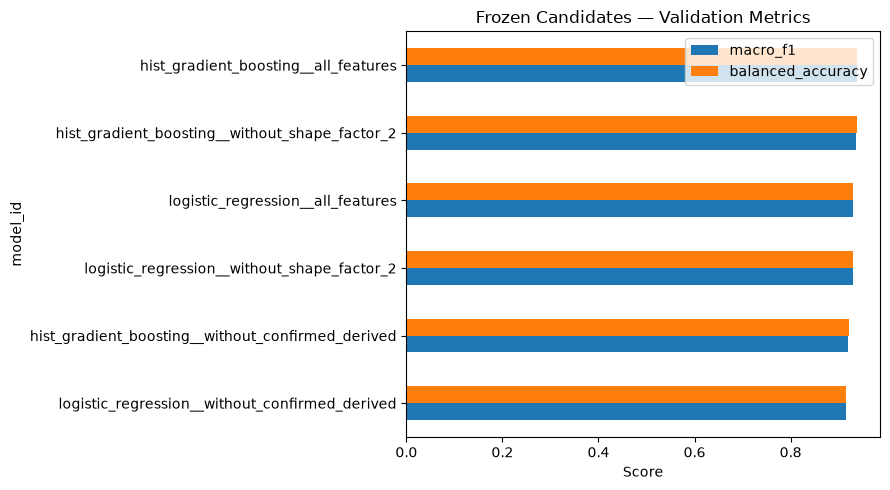

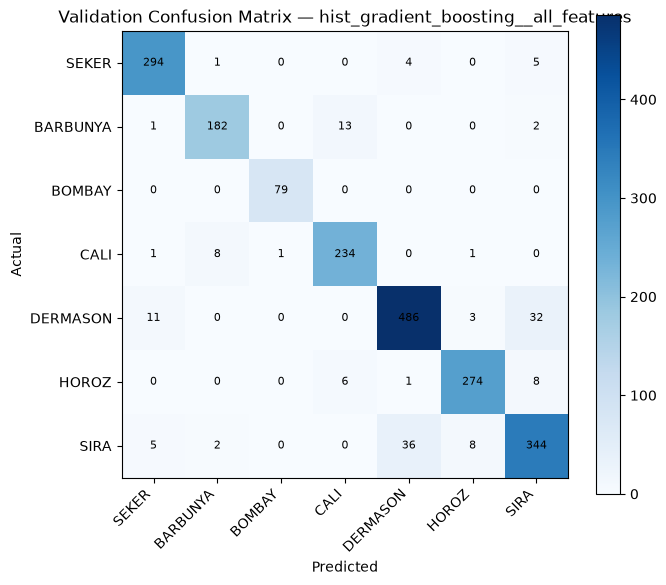

In [28]:
comparison = validation_table.set_index("model_id")[["macro_f1", "balanced_accuracy"]].sort_values("macro_f1")
validation_comparison_axis = comparison.plot(kind="barh")
validation_comparison_figure = validation_comparison_axis.figure
plt.title("Frozen Candidates — Validation Metrics")
plt.xlabel("Score")
plt.tight_layout()
export_figure(
    validation_comparison_figure,
    PROJECT.root / "docs/images/model_validation_comparison.png",
)
plt.show()

matrix = np.asarray(SELECTED_VALIDATION["confusion_matrix"]["counts"])
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(matrix, cmap="Blues")
for row in range(len(TARGET_CLASSES)):
    for column in range(len(TARGET_CLASSES)):
        ax.text(column, row, str(matrix[row, column]), ha="center", va="center", fontsize=8)
ax.set_xticks(range(len(TARGET_CLASSES)), labels=TARGET_CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(TARGET_CLASSES)), labels=TARGET_CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Validation Confusion Matrix — {SELECTED_MODEL_ID}")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


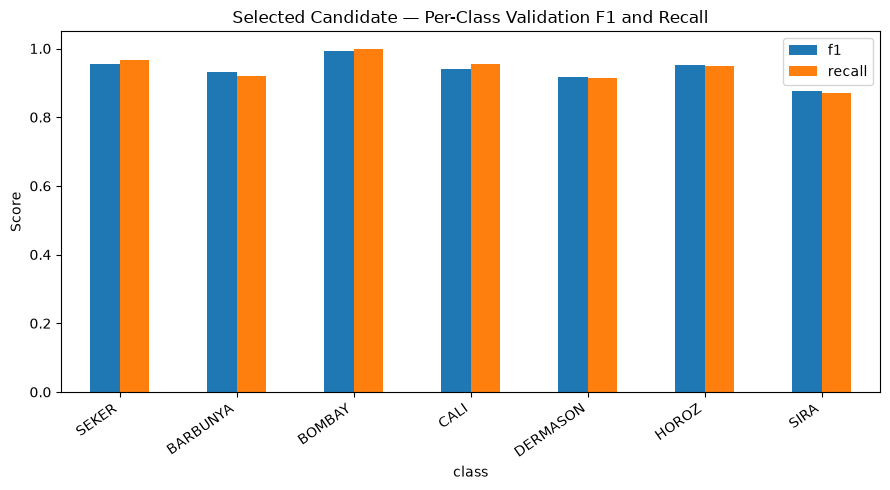

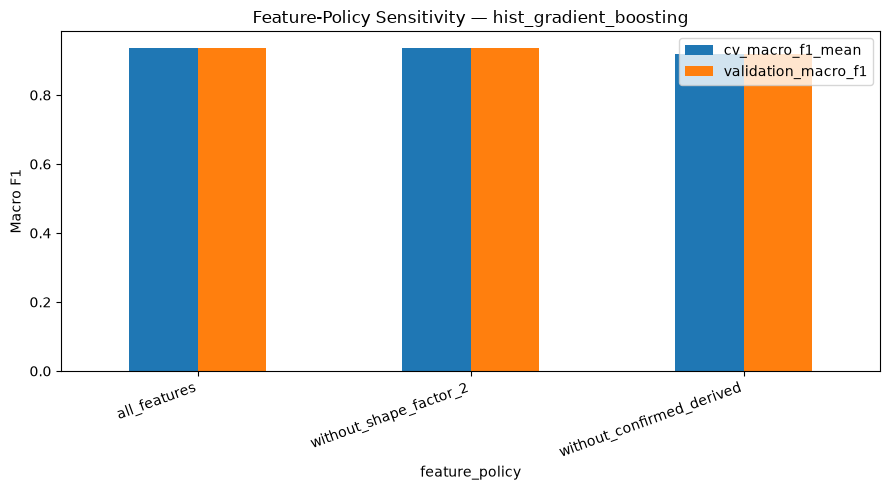

In [29]:
per_class_table.set_index("class")[["f1", "recall"]].plot(kind="bar")
plt.title("Selected Candidate — Per-Class Validation F1 and Recall")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

selected_family_policies = pd.DataFrame([
    ALL_FEATURE_RESULT, WITHOUT_SHAPE_FACTOR_2_RESULT, WITHOUT_CONFIRMED_DERIVED_RESULT
]).set_index("feature_policy")
feature_policy_axis = selected_family_policies[["cv_macro_f1_mean", "validation_macro_f1"]].plot(kind="bar")
feature_policy_figure = feature_policy_axis.figure
plt.title(f"Feature-Policy Sensitivity — {SELECTED_BASE_MODEL_ID}")
plt.ylabel("Macro F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
export_figure(
    feature_policy_figure,
    PROJECT.root / "docs/images/feature_policy_sensitivity.png",
)
plt.show()


## 13. Candidate Selection and Frozen Policy

The selected object is a declarative final-training candidate, not a final model artifact. Model family, hyperparameters, feature policy, scaling, class weighting, class order, CV, decision rule, and validation evidence are frozen before any future test access.


In [30]:
SELECTED_PREPROCESSING_CONTRACT = {
    "pipeline": "sklearn.pipeline.Pipeline",
    "feature_projection": list(SELECTED_FEATURE_COLUMNS),
    "numerical_scaling": "standard_scaler" if spec_by_id[SELECTED_BASE_MODEL_ID]["scale_features"] else "none",
    "scaling_fit_scope": "inside_training_fold_or_final_training_only",
    "categorical_processing": "not_applicable",
    "learned_preprocessing_in_notebook_02": False,
}
SELECTED_IMBALANCE_POLICY = {
    "strategy": IMBALANCE_ANALYSIS["selected_policy"],
    "class_weight": selected_class_weight,
    "resampling": "none",
}
FROZEN_POLICY = {
    "selected_model_id": SELECTED_MODEL_ID,
    "selected_base_model_id": SELECTED_BASE_MODEL_ID,
    "selected_model_family": SELECTED_MODEL_FAMILY,
    "selected_hyperparameters": SELECTED_HYPERPARAMETERS,
    "selected_feature_policy": SELECTED_FEATURE_POLICY,
    "selected_feature_columns": list(SELECTED_FEATURE_COLUMNS),
    "selected_preprocessing": SELECTED_PREPROCESSING_CONTRACT,
    "selected_imbalance_policy": SELECTED_IMBALANCE_POLICY,
    "decision_rule": "argmax_class_score_or_probability",
    "positive_class": None,
    "binary_threshold": "not_applicable",
}
print(json.dumps(FROZEN_POLICY, indent=2, sort_keys=True))


{
  "binary_threshold": "not_applicable",
  "decision_rule": "argmax_class_score_or_probability",
  "positive_class": null,
  "selected_base_model_id": "hist_gradient_boosting",
  "selected_feature_columns": [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "AspectRatio",
    "Eccentricity",
    "ConvexArea",
    "EquivDiameter",
    "Extent",
    "Solidity",
    "Roundness",
    "Compactness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor3",
    "ShapeFactor4"
  ],
  "selected_feature_policy": "all_features",
  "selected_hyperparameters": {
    "model__class_weight": null,
    "model__l2_regularization": 0.0,
    "model__learning_rate": 0.05,
    "model__max_iter": 250,
    "model__max_leaf_nodes": 15,
    "model__min_samples_leaf": 40
  },
  "selected_imbalance_policy": {
    "class_weight": null,
    "resampling": "none",
    "strategy": "none"
  },
  "selected_model_family": "HistGradientBoostingClassifier",
  "selected_model_id": "hist_gra

## 14. Artifact Materialization


In [31]:
PREPARATION_HANDOFF_REFERENCE = {
    "path": PREPARATION_HANDOFF_PATH.as_posix(),
    "byte_sha256": sha256_file(PROJECT.root / PREPARATION_HANDOFF_PATH),
    "schema_version": preparation_handoff_manifest["schema_version"],
}
PREPARATION_ARTIFACT_HASHES = {
    **{
        f"{name}_sha256": reference["sha256"]
        for name, reference in preparation_handoff_manifest["components"].items()
    },
    "prepared_sha256": preparation_manifest["prepared_sha256"],
    "train_sha256": split_manifest["partition_sha256"]["train"],
    "validation_sha256": split_manifest["partition_sha256"]["validation"],
    "test_sha256_integrity_reference_only": split_manifest["partition_sha256"]["test"],
}
RANDOM_SEEDS = {
    "split_reference": split_manifest["random_seed"],
    "cross_validation": RANDOM_SEED,
    "randomized_search": RANDOM_SEED,
    "estimators": RANDOM_SEED,
}
SECONDARY_METRICS = [
    "balanced_accuracy", "macro_recall", "weighted_f1", "accuracy_context_only",
    "per_class_precision", "per_class_recall", "per_class_f1", "support",
    "confusion_matrix", "multiclass_log_loss",
]
READINESS = {
    "preparation_handoff_validated": True,
    "frozen_partitions_respected": True,
    "multiclass_cv_completed": True,
    "candidate_models_evaluated": True,
    "feature_policy_evaluated": True,
    "imbalance_policy_frozen": True,
    "selected_candidate_frozen": True,
    "multiclass_decision_rule_frozen": True,
    "model_selection_handoff_reloadable": True,
    "test_partition_sealed": True,
    "test_partition_evaluated": False,
    "final_model_training_ready": True,
    "final_model_trained": False,
    "model_artifact_materialized": False,
    "model_bundle_materialized": False,
    "operational_modeling_ready": False,
    "operational_validity": "unconfirmed",
}
ANALYSIS_CONCLUSIONS = {
    "shape_factor_2": SHAPE_FACTOR_2_ANALYSIS,
    "confirmed_derived_feature_ablation": DERIVED_FEATURE_ABLATION,
    "overlap_hypothesis": {
        "status": OVERLAP_HYPOTHESIS["status"],
        "focal_pair_rank": OVERLAP_HYPOTHESIS["focal_pair_rank"],
        "highest_confusion_pair": OVERLAP_HYPOTHESIS["ranked_pairs"][0],
    },
    "repeated_profile_sensitivity": REPEATED_PROFILE_SENSITIVITY,
    "feature_reduction_hypothesis": {
        "hypothesis_id": "HYP-001", "status": HYPOTHESIS_001_STATUS,
    },
}
FINAL_TRAINING_INSTRUCTIONS = {
    "notebook": "notebooks/04_final_model_and_bundle.ipynb",
    "reconstruct_pipeline_from_contract": True,
    "fit_partitions": ["train", "validation"],
    "final_evaluation_partition": "test",
    "access_test_only_after_contract_freeze_and_final_fit": True,
    "evaluate_test_once": True,
    "do_not_retune": True,
    "do_not_change_feature_policy": True,
    "do_not_change_imbalance_policy": True,
    "do_not_change_hyperparameters": True,
    "decision_rule": "argmax_class_score_or_probability",
}

MODEL_SELECTION_HANDOFF = build_multiclass_model_selection_handoff(
    dataset_slug=DATASET_SLUG,
    preparation_handoff_reference=PREPARATION_HANDOFF_REFERENCE,
    preparation_artifact_hashes=PREPARATION_ARTIFACT_HASHES,
    target_column=TARGET_COLUMN,
    target_classes=TARGET_CLASSES,
    target_encoding=TARGET_ENCODING,
    available_feature_columns=FEATURE_COLUMNS,
    selected_feature_columns=SELECTED_FEATURE_COLUMNS,
    selected_feature_policy=SELECTED_FEATURE_POLICY,
    selected_model_id=SELECTED_MODEL_ID,
    selected_model_family=SELECTED_MODEL_FAMILY,
    selected_hyperparameters=SELECTED_HYPERPARAMETERS,
    selected_preprocessing_contract=SELECTED_PREPROCESSING_CONTRACT,
    selected_imbalance_policy=SELECTED_IMBALANCE_POLICY,
    cv_contract={**MODEL_SELECTION_CONTRACT["cv"], "folds": CV_FOLD_DISTRIBUTIONS, "fit_partition": "train_only"},
    random_seeds=RANDOM_SEEDS,
    primary_metric="macro_f1",
    secondary_metrics=SECONDARY_METRICS,
    selected_cv_evidence=SELECTED_POLICY_SUMMARY,
    selected_validation_evidence=SELECTED_VALIDATION,
    selection_rationale=SELECTION["selection_rationale"],
    tie_break_rationale={
        "practical_tie": SELECTION["practical_tie"],
        "tolerance": PRACTICAL_TIE_TOLERANCE,
        "order": SELECTION["tie_break_order"],
    },
    analysis_conclusions=ANALYSIS_CONCLUSIONS,
    final_training_instructions=FINAL_TRAINING_INSTRUCTIONS,
    readiness=READINESS,
)

VALIDATION_EVIDENCE = build_multiclass_validation_evidence(
    dataset_slug=DATASET_SLUG,
    target_classes=TARGET_CLASSES,
    baseline_evaluation=DUMMY_VALIDATION,
    evaluations=VALIDATION_EVALUATIONS,
    selection=SELECTION,
)
SELECTION_ANALYSIS = build_multiclass_selection_analysis(
    dataset_slug=DATASET_SLUG,
    imbalance_analysis=IMBALANCE_ANALYSIS,
    feature_policy_analysis=FEATURE_POLICY_ANALYSIS,
    shape_factor_2_analysis=SHAPE_FACTOR_2_ANALYSIS,
    derived_feature_ablation=DERIVED_FEATURE_ABLATION,
    overlap_hypothesis=OVERLAP_HYPOTHESIS,
    repeated_profile_sensitivity=REPEATED_PROFILE_SENSITIVITY,
    tie_analysis={
        "practical_tie": SELECTION["practical_tie"],
        "tolerance": PRACTICAL_TIE_TOLERANCE,
        "order": SELECTION["tie_break_order"],
        "finalists": SELECTION["finalists"],
    },
    selection_rationale=SELECTION["selection_rationale"],
)
CANDIDATE_RESULTS = build_multiclass_candidate_results(
    baseline_cv=DUMMY_CV,
    baseline_validation=DUMMY_VALIDATION,
    family_search_summaries=list(FAMILY_SUMMARIES.values()),
    policy_cv_summaries=POLICY_CV_SUMMARIES,
    validation_evaluations=VALIDATION_EVALUATIONS,
    selection=SELECTION,
    warnings_by_model=WARNINGS_BY_MODEL,
)

CROSS_VALIDATION_RESULTS = pd.concat(
    [*FAMILY_CV_TABLES, pd.DataFrame(policy_cv_rows)], ignore_index=True, sort=False
)
ARTIFACT_PATHS = {
    filename: (MODEL_SELECTION_ROOT / filename).as_posix()
    for filename in MULTICLASS_ARTIFACT_FILENAMES
}
MODEL_SELECTION_MANIFEST = build_multiclass_model_selection_manifest(
    dataset_slug=DATASET_SLUG,
    preparation_handoff_reference=PREPARATION_HANDOFF_REFERENCE,
    preparation_artifact_hashes=PREPARATION_ARTIFACT_HASHES,
    model_selection_contract=MODEL_SELECTION_CONTRACT,
    candidate_families=[
        {key: spec[key] for key in ("model_id", "family", "scale_features", "search_strategy", "search_space")}
        | {"n_iter": spec.get("n_iter")}
        for spec in CANDIDATE_SPECS
    ],
    feature_policies=FEATURE_POLICIES,
    cv_contract={**MODEL_SELECTION_CONTRACT["cv"], "folds": CV_FOLD_DISTRIBUTIONS, "fit_partition": "train_only"},
    scoring_contract={
        "primary_metric": "macro_f1", "refit_metric": "macro_f1",
        "secondary_metrics": SECONDARY_METRICS,
    },
    search_contract={
        "phases": ["family_search", "cv_shortlist", "feature_policy_sensitivity", "validation_once", "freeze"],
        "validation_in_search": False, "test_in_search": False,
        "search_n_jobs": SEARCH_N_JOBS, "estimator_n_jobs": ESTIMATOR_N_JOBS,
    },
    random_seeds=RANDOM_SEEDS,
    artifact_paths=ARTIFACT_PATHS,
    readiness=READINESS,
    limitations=[
        "Educational stratified-random snapshot benchmark only.",
        "Operational validity and inference-time feature availability remain unconfirmed.",
        "ShapeFactor2 source provenance remains unresolved; only predictive sensitivity was evaluated.",
        "Repeated-profile evidence does not prove duplicate identity or leakage.",
        "Notebook 04 must be generalized for the multiclass v2 handoff before final fitting.",
        "Test remains sealed and no final model or bundle exists.",
    ],
)

ARTIFACT_PAYLOADS = {
    "model-selection-manifest.json": MODEL_SELECTION_MANIFEST,
    "candidate-results.json": CANDIDATE_RESULTS,
    "cross-validation-results.csv": CROSS_VALIDATION_RESULTS,
    "validation-evidence.json": VALIDATION_EVIDENCE,
    "selection-analysis.json": SELECTION_ANALYSIS,
    "model-selection-handoff.json": MODEL_SELECTION_HANDOFF,
}
WRITE_RESULT = write_multiclass_model_selection_artifacts(
    output_directory=PROJECT.root / MODEL_SELECTION_ROOT,
    artifacts=ARTIFACT_PAYLOADS,
    overwrite=False,
)
print("Artifact materialization:", {
    "created": list(WRITE_RESULT.created),
    "replaced": list(WRITE_RESULT.replaced),
    "idempotent": WRITE_RESULT.idempotent,
})


Artifact materialization: {'created': [], 'replaced': [], 'idempotent': True}


## 15. Model-Selection Handoff Validation

The persisted v2 handoff and every sibling fingerprint are reloaded. It must recover the exact seven-class contract and frozen candidate while proving that test is sealed, final fitting has not occurred, and model/bundle artifacts are absent.


In [32]:
RELOADED_HANDOFF = load_and_validate_model_selection_handoff(
    project_root=PROJECT.root,
    handoff_path=MODEL_SELECTION_ROOT / "model-selection-handoff.json",
)
assert RELOADED_HANDOFF["dataset_slug"] == "dry-bean"
assert tuple(RELOADED_HANDOFF["target_classes"]) == TARGET_CLASSES
assert tuple(RELOADED_HANDOFF["selected_feature_columns"]) == SELECTED_FEATURE_COLUMNS
assert RELOADED_HANDOFF["selected_model_id"] == SELECTED_MODEL_ID
assert RELOADED_HANDOFF["selected_hyperparameters"] == SELECTED_HYPERPARAMETERS
assert RELOADED_HANDOFF["positive_class"] is None
assert RELOADED_HANDOFF["binary_threshold"]["status"] == "not_applicable"
assert RELOADED_HANDOFF["test_partition_sealed"] is True
assert RELOADED_HANDOFF["test_partition_evaluated"] is False
assert RELOADED_HANDOFF["final_model_trained"] is False
assert RELOADED_HANDOFF["model_artifact"] is None
assert RELOADED_HANDOFF["bundle"] is None

final_report = {
    "handoff": (MODEL_SELECTION_ROOT / "model-selection-handoff.json").as_posix(),
    "selected_model_id": RELOADED_HANDOFF["selected_model_id"],
    "selected_model_family": RELOADED_HANDOFF["selected_model_family"],
    "selected_feature_policy": RELOADED_HANDOFF["selected_feature_policy"],
    "selected_feature_count": len(RELOADED_HANDOFF["selected_feature_columns"]),
    "validation_metrics": RELOADED_HANDOFF["selected_validation_evidence"]["metrics"],
    "test_partition_sealed": RELOADED_HANDOFF["test_partition_sealed"],
    "test_partition_evaluated": RELOADED_HANDOFF["test_partition_evaluated"],
    "final_model_trained": RELOADED_HANDOFF["final_model_trained"],
    "model_artifact_materialized": RELOADED_HANDOFF["model_artifact_materialized"],
    "model_bundle_materialized": RELOADED_HANDOFF["model_bundle_materialized"],
    "operational_validity": RELOADED_HANDOFF["operational_validity"],
}
print(json.dumps(final_report, indent=2, sort_keys=True))
print("Notebook 03 complete: candidate frozen; test metrics calculated = False.")


{
  "final_model_trained": false,
  "handoff": "artifacts/model-selection/dry-bean/model-selection-handoff.json",
  "model_artifact_materialized": false,
  "model_bundle_materialized": false,
  "operational_validity": "unconfirmed",
  "selected_feature_count": 16,
  "selected_feature_policy": "all_features",
  "selected_model_family": "HistGradientBoostingClassifier",
  "selected_model_id": "hist_gradient_boosting__all_features",
  "test_partition_evaluated": false,
  "test_partition_sealed": true,
  "validation_metrics": {
    "accuracy": 0.9270323212536729,
    "balanced_accuracy": 0.9391308599307318,
    "log_loss": 0.22517215001326799,
    "macro_f1": 0.9378814348554879,
    "macro_recall": 0.9391308599307318,
    "minimum_per_class_recall": 0.8708860759493671,
    "row_count": 2042,
    "weighted_f1": 0.9268991730331414
  }
}
Notebook 03 complete: candidate frozen; test metrics calculated = False.
